# Part IV: Sentiment analysis using LSTM [20 points]
In this part, we perform a sentiment analysis using LSTM model. The final (improved) model should achieve a test accuracy of greater than 75%.

## Step 1: Data exploration and preprocessing

1. Load your chosen dataset and print the main statistics

In [ ]:
### ADD YOUR CODE HERE ###
import pandas as pd

ds = pd.read_csv('Tweets.csv')
print(ds.describe())


           tweet_id  airline_sentiment_confidence  negativereason_confidence  \
count  1.464000e+04                  14640.000000               10522.000000   
mean   5.692184e+17                      0.900169                   0.638298   
std    7.791112e+14                      0.162830                   0.330440   
min    5.675883e+17                      0.335000                   0.000000   
25%    5.685592e+17                      0.692300                   0.360600   
50%    5.694779e+17                      1.000000                   0.670600   
75%    5.698905e+17                      1.000000                   1.000000   
max    5.703106e+17                      1.000000                   1.000000   

       retweet_count  
count   14640.000000  
mean        0.082650  
std         0.745778  
min         0.000000  
25%         0.000000  
50%         0.000000  
75%         0.000000  
max        44.000000  


2. Print the first 5 rows of the dataset to understand its structure

In [2]:
### ADD YOUR CODE HERE ###
print(ds.head(5))

             tweet_id airline_sentiment  airline_sentiment_confidence  \
0  570306133677760513           neutral                        1.0000   
1  570301130888122368          positive                        0.3486   
2  570301083672813571           neutral                        0.6837   
3  570301031407624196          negative                        1.0000   
4  570300817074462722          negative                        1.0000   

  negativereason  negativereason_confidence         airline  \
0            NaN                        NaN  Virgin America   
1            NaN                     0.0000  Virgin America   
2            NaN                        NaN  Virgin America   
3     Bad Flight                     0.7033  Virgin America   
4     Can't Tell                     1.0000  Virgin America   

  airline_sentiment_gold        name negativereason_gold  retweet_count  \
0                    NaN     cairdin                 NaN              0   
1                    NaN    jnar

3. Provide a brief description of the dataset

<span style='color:green'>### YOUR ANSWER ###</span>

This dataset contains tweet data directed towards airlines, primarily for sentiment analysis. It contains several attributes like tweet_id, the actual tweet text, the airline, and tweet sentiment. The most important interest in the data set is the airline_sentiment column, which classifies the tweet as positive, neutral, or negative, representing the overall user sentiment of the tweet regarding the airline. Other columns have confidence scores, potential reasons for the negative sentiment, retweet count, and user-specific information such as location and timezone.
 link to the source: https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment



4. Display descriptive statistics

In [ ]:
### ADD YOUR CODE HERE ###
import pandas as pd
import numpy as np
ds = pd.read_csv('Tweets.csv')
num_samp = len(ds)
class_distribution = ds['airline_sentiment'].value_counts(normalize=True) * 100
ds['text_length_words'] = ds['text'].apply(lambda x: len(x.split()))
ds['text_length_chars'] = ds['text'].apply(len)
avg_len_words = ds['text_length_words'].mean()
avg_len_chars = ds['text_length_chars'].mean()
all_words = ' '.join(ds['text']).split()
vocab_size = len(set(all_words))
print(f"Number of samples: {num_samp}")
print("\nClass distribution (percentage):")
print(class_distribution)
print(f"\nAverage review length (in words): {avg_len_words:.2f}")
print(f"Average review length (in characters): {avg_len_chars:.2f}")
print(f"\nVocabulary size (number of unique words): {vocab_size}")

Number of samples: 14640

Class distribution (percentage):
airline_sentiment
negative    62.691257
neutral     21.168033
positive    16.140710
Name: proportion, dtype: float64

Average review length (in words): 17.65
Average review length (in characters): 103.82

Vocabulary size (number of unique words): 30105


5. Handle missing values

In [4]:
### ADD YOUR CODE HERE ###
#missing values
print("Missing values in each column:")
missing_values = ds.isnull().sum()
missing_percentage = (missing_values / len(ds)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})
print(missing_df[missing_df['Missing Values'] > 0])  #show columns with missing values

text_columns = ['text', 'text_normalized', 'tweet', 'review']
for col in text_columns:
    if col in ds.columns:
        ds[col] = ds[col].fillna('')

remaining_missing = ds.isnull().sum().sum()
print(f"\nRemaining missing values after handling: {remaining_missing}")

Missing values in each column:
                           Missing Values  Percentage
negativereason                       5462   37.308743
negativereason_confidence            4118   28.128415
airline_sentiment_gold              14600   99.726776
negativereason_gold                 14608   99.781421
tweet_coord                         13621   93.039617
tweet_location                       4733   32.329235
user_timezone                        4820   32.923497

Remaining missing values after handling: 61962


In [5]:

categorical_columns = ['airline_sentiment', 'negativereason', 'airline', 'tweet_location', 'user_timezone']
for col in categorical_columns:
    if col in ds.columns and ds[col].isnull().sum() > 0:
        most_frequent = ds[col].mode()[0]
        ds[col] = ds[col].fillna(most_frequent)
        print(f"Filled missing values in '{col}' with '{most_frequent}'")
numerical_columns = ['negativereason_confidence', 'airline_sentiment_confidence']
for col in numerical_columns:
    if col in ds.columns and ds[col].isnull().sum() > 0:
        median_value = ds[col].median()
        ds[col] = ds[col].fillna(median_value)
        print(f"Filled missing values in '{col}' with median: {median_value:.4f}")
if 'tweet_coord' in ds.columns and ds['tweet_coord'].isnull().sum() > 0:
    ds['tweet_coord'] = ds['tweet_coord'].fillna('[0.0, 0.0]')
    print("Filled missing tweet_coord with '[0.0, 0.0]'")
gold_columns = [col for col in ds.columns if 'gold' in col]
for col in gold_columns:
    if ds[col].isnull().sum() > 0:
        if col == 'airline_sentiment_gold' and 'airline_sentiment' in ds.columns:
            ds[col] = ds[col].fillna(ds['airline_sentiment'])
            print(f"Filled missing values in '{col}' with values from 'airline_sentiment'")
        elif col == 'negativereason_gold' and 'negativereason' in ds.columns:
            ds[col] = ds[col].fillna(ds['negativereason'])
            print(f"Filled missing values in '{col}' with values from 'negativereason'")
        else:

            ds[col] = ds[col].fillna('not_labeled')
            print(f"Filled missing values in '{col}' with 'not_labeled'")
remaining_missing = ds.isnull().sum().sum()
print(f"\nRemaining missing values after handling: {remaining_missing}")
missing_after = ds.isnull().sum()
if missing_after.sum() > 0:
    print("\nColumns still containing missing values:")
    print(missing_after[missing_after > 0])

Filled missing values in 'negativereason' with 'Customer Service Issue'
Filled missing values in 'tweet_location' with 'Boston, MA'
Filled missing values in 'user_timezone' with 'Eastern Time (US & Canada)'
Filled missing values in 'negativereason_confidence' with median: 0.6706
Filled missing tweet_coord with '[0.0, 0.0]'
Filled missing values in 'airline_sentiment_gold' with values from 'airline_sentiment'
Filled missing values in 'negativereason_gold' with values from 'negativereason'

Remaining missing values after handling: 0


<span style='color:green'>### YOUR ANSWER ###</span>

6. Create visualizations to gain insights into the data

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
<ipython-input-22-2516c46f7569>:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


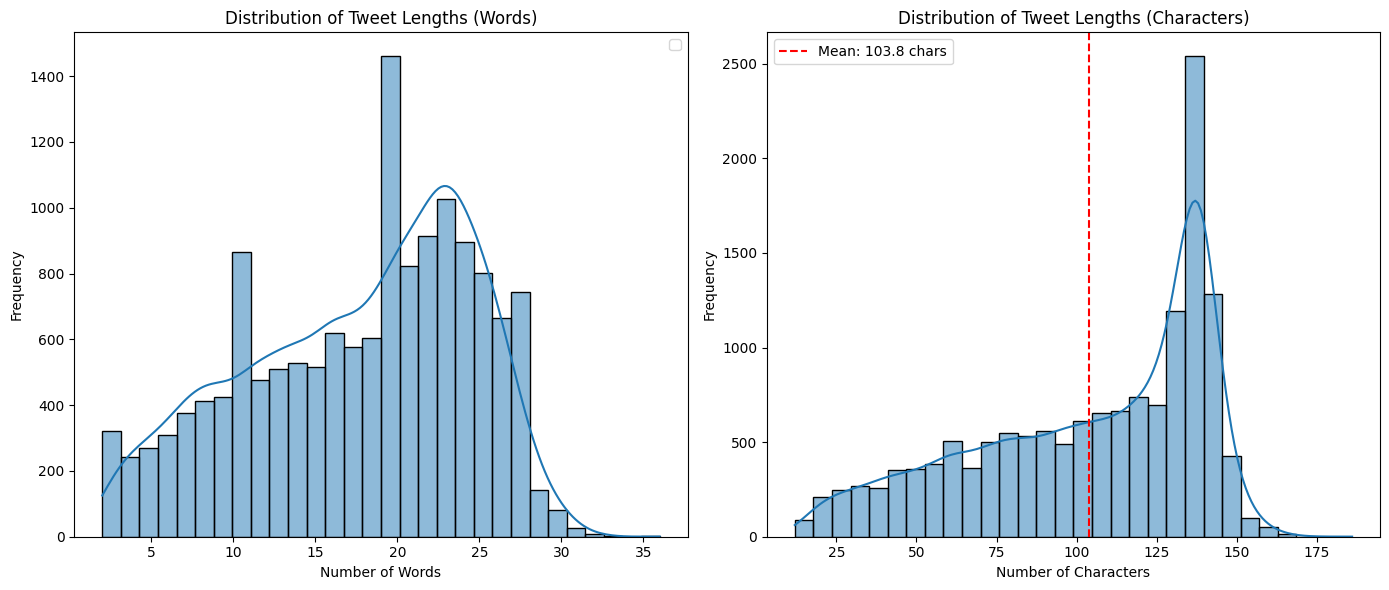

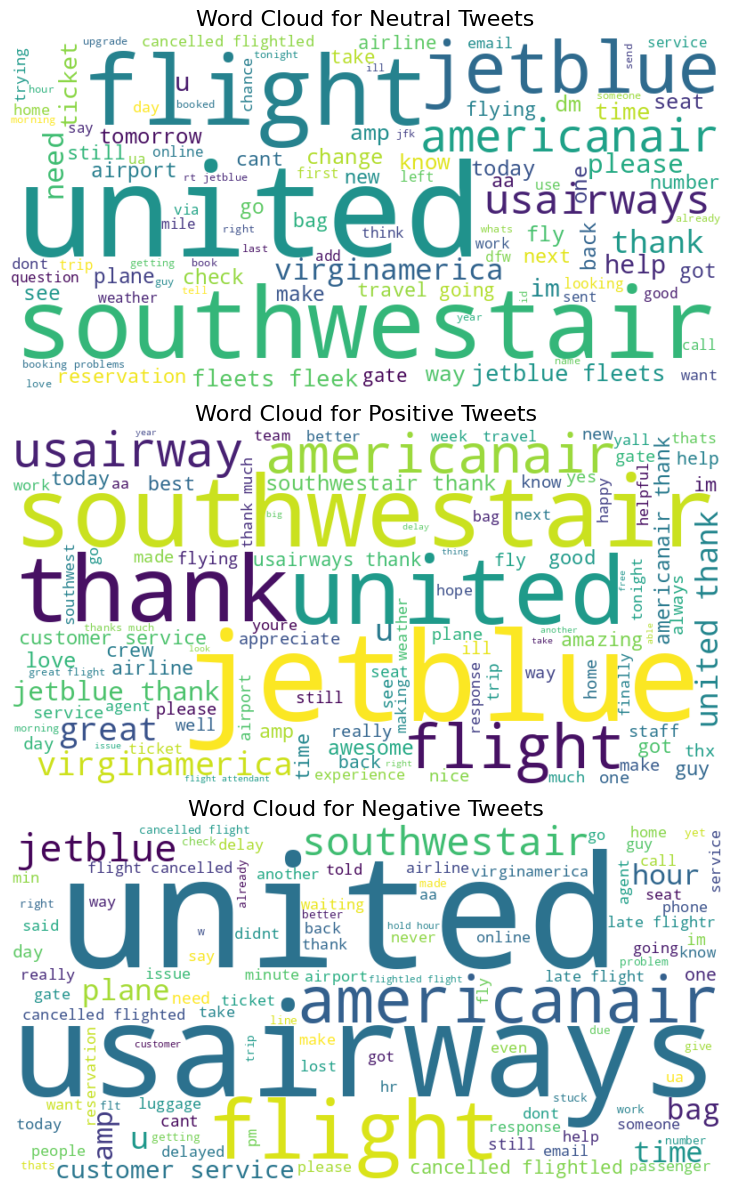

<ipython-input-22-2516c46f7569>:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=colors)


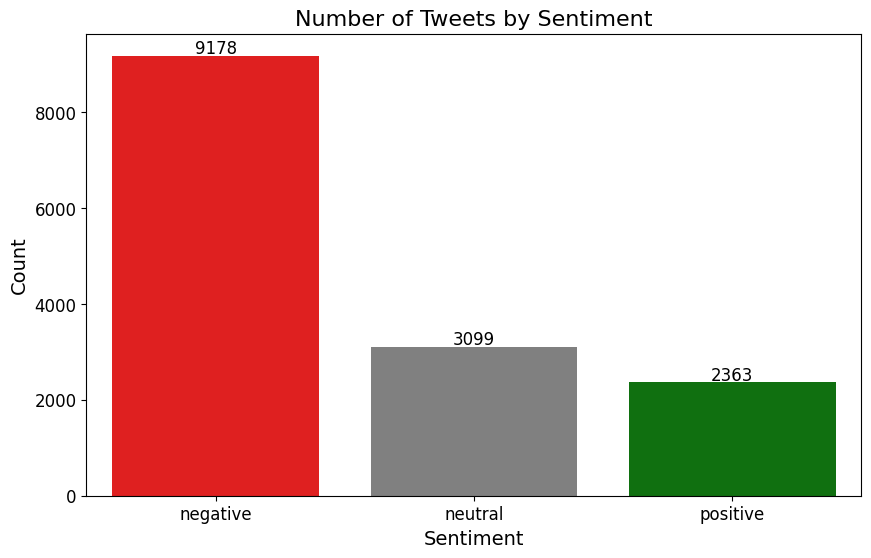

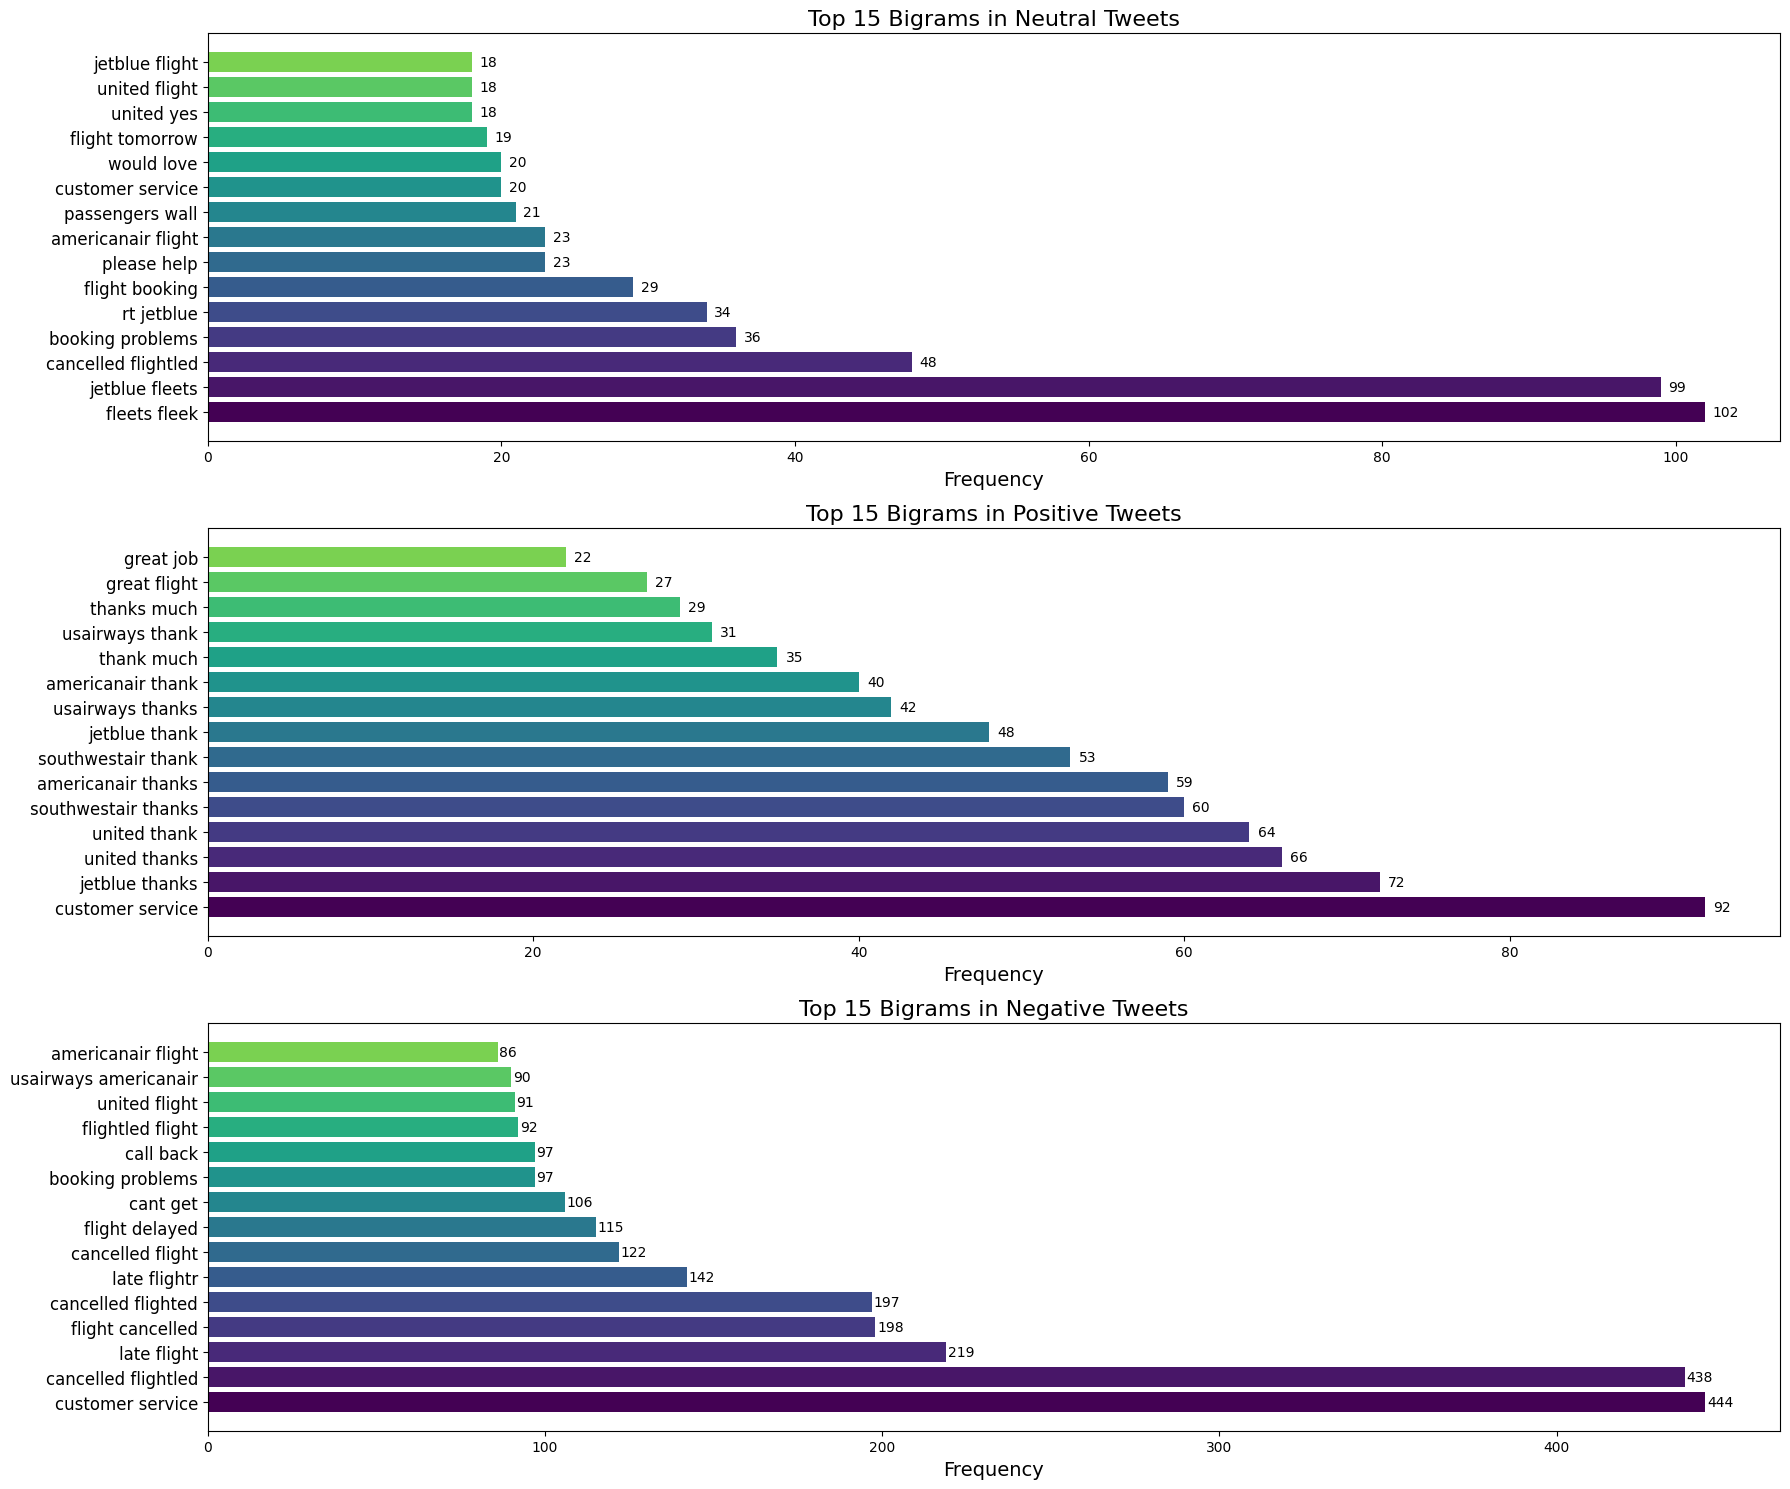

In [ ]:
### ADD YOUR CODE HERE ###
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt')

plt.figure(figsize=(14, 6))

# histogram
plt.subplot(1, 2, 1)
sns.histplot(ds['text_length_words'], kde=True, bins=30)
plt.title('Distribution of Tweet Lengths (Words)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

plt.legend()

# histogram
plt.subplot(1, 2, 2)
sns.histplot(ds['text_length_chars'], kde=True, bins=30)
plt.title('Distribution of Tweet Lengths (Characters)')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.savefig('tweet_length_distributions.png')
plt.show()

#Word clouds for each sentiment class
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)
plt.figure(figsize=(16, 12))

sentiment_classes = ds['airline_sentiment'].unique()

for i, sentiment in enumerate(sentiment_classes):

    sentiment_tweets = ds[ds['airline_sentiment'] == sentiment]['text']


    all_text = ' '.join(sentiment_tweets)
    cleaned_text = clean_text(all_text)
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=100,
        colormap='viridis',
        contour_width=1,
        contour_color='steelblue'
    ).generate(cleaned_text)
    plt.subplot(len(sentiment_classes), 1, i+1)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud for {sentiment.capitalize()} Tweets', fontsize=16)
    plt.axis('off')
plt.tight_layout()
plt.savefig('sentiment_wordclouds.png')
plt.show()

#Bar chart
plt.figure(figsize=(10, 6))
sentiment_counts = ds['airline_sentiment'].value_counts()
palette = {'negative': 'red', 'neutral': 'grey', 'positive': 'green'}
colors = [palette.get(sentiment, 'blue') for sentiment in sentiment_counts.index]
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=colors)
plt.title('Number of Tweets by Sentiment', fontsize=16)
plt.xlabel('Sentiment', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
for i, count in enumerate(sentiment_counts.values):
    plt.text(i, count + 50, f'{count}', ha='center', fontsize=12)

plt.savefig('sentiment_counts.png')
plt.show()
from nltk import ngrams

def get_top_ngrams(corpus, n=2, top_k=15):
    all_ngrams = []
    for text in corpus:
        cleaned = clean_text(text)
        tokens = cleaned.split()
        n_grams = list(ngrams(tokens, n))
        all_ngrams.extend([' '.join(g) for g in n_grams])
    ngram_freq = Counter(all_ngrams)
    top_ngrams = ngram_freq.most_common(top_k)

    return top_ngrams
plt.figure(figsize=(18, 15))

for i, sentiment in enumerate(sentiment_classes):
    sentiment_tweets = ds[ds['airline_sentiment'] == sentiment]['text']
    top_bigrams = get_top_ngrams(sentiment_tweets, n=2, top_k=15)
    words, counts = zip(*top_bigrams)
    plt.subplot(len(sentiment_classes), 1, i+1)
    colors = plt.cm.viridis(np.linspace(0, 0.8, len(words)))
    plt.barh(range(len(words)), counts, color=colors)
    plt.yticks(range(len(words)), words, fontsize=12)
    plt.title(f'Top 15 Bigrams in {sentiment.capitalize()} Tweets', fontsize=16)
    plt.xlabel('Frequency', fontsize=14)
    for j, count in enumerate(counts):
        plt.text(count + 0.5, j, str(count), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('top_bigrams_by_sentiment.png')
plt.show()



7. Data preparation

In [6]:
!pip install nltk

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Training set: 11712 examples
Validation set: 1464 examples
Test set: 1464 examples

Tokenization Methods Comparison:

NLTK Word Tokenizer:
  Processing time: 0.2892 seconds
  Vocabulary size: 2870 unique tokens
  Avg tokens per text: 16.11
  Example: ['what', 'would', 'it', 'cost']

NLTK Tweet Tokenizer:
  Processing time: 0.3191 seconds
  Vocabulary size: 2863 unique tokens
  Avg tokens per text: 16.11
  Example: ['what', 'would', 'it', 'cost']

Custom Twitter Tokenizer:
  Processing time: 0.0350 seconds
  Vocabulary size: 3030 unique tokens
  Avg tokens per text: 17.52
  Example: ['<USER>', 'what', 'would', 'it', 'cost']

Tokenizing all data with the chosen tokenizer...

Building vocabulary from training data...
Total unique tokens in training data: 11618
Tokens with frequency >= 2: 5403
Final vocabulary size: 5405
Sample vocabulary items: [('<PAD>', 0), ('<UNK>', 1), ('what', 2), ('would', 3), ('it', 4), ('cost', 5), ('used', 6), ('2', 7), ('get', 8), ('emails', 9)]


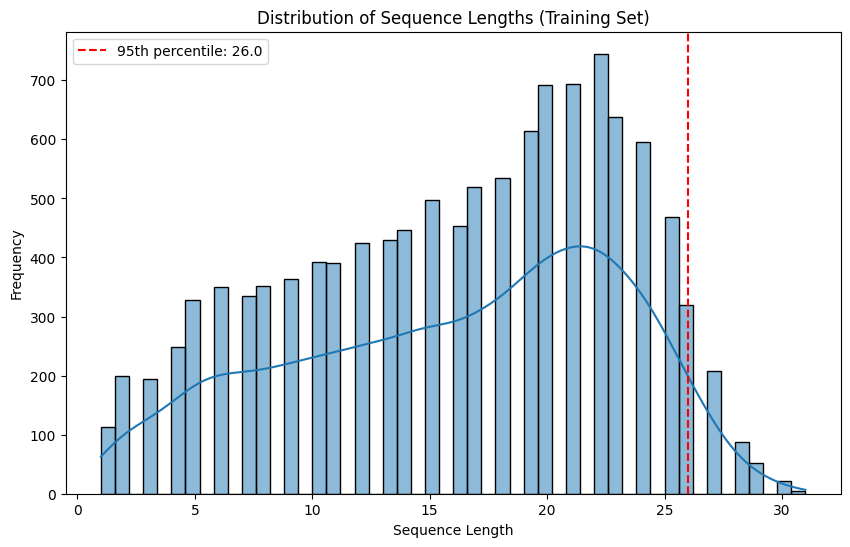


Chosen max_length (95th percentile): 26

Padded sequence shape (train): torch.Size([11712, 26])
Padded sequence shape (val): torch.Size([1464, 26])
Padded sequence shape (test): torch.Size([1464, 26])

Data preparation complete!
Number of batches in training data: 183
Number of batches in validation data: 23
Number of batches in test data: 23


In [7]:
### ADD YOUR CODE HERE ###
import pandas as pd
import numpy as np
import time
import re
import torch
from torch.nn.utils.rnn import pad_sequence
import nltk
from nltk.tokenize import word_tokenize, TweetTokenizer
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
from sklearn.model_selection import train_test_split
sentiment_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
ds['sentiment_label'] = ds['airline_sentiment'].map(sentiment_mapping)
train_df, temp_df = train_test_split(ds, test_size=0.2, random_state=42, stratify=ds['sentiment_label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['sentiment_label'])
print(f"Training set: {len(train_df)} examples")
print(f"Validation set: {len(val_df)} examples")
print(f"Test set: {len(test_df)} examples")
def clean_text(text):
    """Clean text by removing URLs, mentions, hashtags, and special characters"""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
def nltk_word_tokenizer(text):
    return word_tokenize(clean_text(text))

def nltk_tweet_tokenizer(text):
    tweet_tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
    return tweet_tokenizer.tokenize(clean_text(text))
def custom_twitter_tokenizer(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '<URL>', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '<USER>', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^\w\s<>]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.split()
tokenization_methods = {
    'NLTK Word Tokenizer': nltk_word_tokenizer,
    'NLTK Tweet Tokenizer': nltk_tweet_tokenizer,
    'Custom Twitter Tokenizer': custom_twitter_tokenizer
}
sample_texts = train_df['text'].head(1000).tolist()

results = {}
for name, tokenizer in tokenization_methods.items():
    # Measure processing time
    start_time = time.time()
    tokens = [tokenizer(text) for text in sample_texts]
    processing_time = time.time() - start_time

    all_tokens = [token for sublist in tokens for token in sublist]
    vocab_size = len(set(all_tokens))

    avg_tokens = sum(len(t) for t in tokens) / len(tokens)

    results[name] = {
        'processing_time': processing_time,
        'vocab_size': vocab_size,
        'avg_tokens': avg_tokens,
        'example': tokens[0][:10]
    }

print("\nTokenization Methods Comparison:")
for name, stats in results.items():
    print(f"\n{name}:")
    print(f"  Processing time: {stats['processing_time']:.4f} seconds")
    print(f"  Vocabulary size: {stats['vocab_size']} unique tokens")
    print(f"  Avg tokens per text: {stats['avg_tokens']:.2f}")
    print(f"  Example: {stats['example']}")

chosen_tokenizer = nltk_tweet_tokenizer


print("\nTokenizing all data with the chosen tokenizer...")
train_tokens = [chosen_tokenizer(text) for text in train_df['text']]
val_tokens = [chosen_tokenizer(text) for text in val_df['text']]
test_tokens = [chosen_tokenizer(text) for text in test_df['text']]


print("\nBuilding vocabulary from training data...")
token_counts = Counter([token for sublist in train_tokens for token in sublist])
print(f"Total unique tokens in training data: {len(token_counts)}")


min_freq = 2
filtered_tokens = {token: count for token, count in token_counts.items() if count >= min_freq}
print(f"Tokens with frequency >= {min_freq}: {len(filtered_tokens)}")

vocab = {'<PAD>': 0, '<UNK>': 1}
for i, (token, _) in enumerate(filtered_tokens.items()):
    vocab[token] = i + 2  #+2 because we already have <PAD> and <UNK>

print(f"Final vocabulary size: {len(vocab)}")
print(f"Sample vocabulary items: {list(vocab.items())[:10]}")

idx_to_token = {idx: token for token, idx in vocab.items()}

def tokens_to_indices(tokens, vocab):
    return [vocab.get(token, vocab['<UNK>']) for token in tokens]

train_indices = [tokens_to_indices(tokens, vocab) for tokens in train_tokens]
val_indices = [tokens_to_indices(tokens, vocab) for tokens in val_tokens]
test_indices = [tokens_to_indices(tokens, vocab) for tokens in test_tokens]

#analyzing sequence lengths to determine appropriate padding length
train_lengths = [len(seq) for seq in train_indices]
val_lengths = [len(seq) for seq in val_indices]
test_lengths = [len(seq) for seq in test_indices]

plt.figure(figsize=(10, 6))
sns.histplot(train_lengths, kde=True, bins=50)
plt.axvline(x=np.percentile(train_lengths, 95), color='red', linestyle='--',
            label=f'95th percentile: {np.percentile(train_lengths, 95):.1f}')
plt.title('Distribution of Sequence Lengths (Training Set)')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.legend()
plt.savefig('sequence_length_distribution.png')
plt.show()

#max length based on 95th percentile of training data
max_length = int(np.percentile(train_lengths, 95))
print(f"\nChosen max_length (95th percentile): {max_length}")
def pad_sequences(sequences, max_len, padding_value=0):
    sequences_tensor = [torch.tensor(seq[:max_len]) for seq in sequences]
    padded_sequences = pad_sequence(sequences_tensor, batch_first=True, padding_value=padding_value)
    return padded_sequences
train_padded = pad_sequences(train_indices, max_length)
val_padded = pad_sequences(val_indices, max_length)
test_padded = pad_sequences(test_indices, max_length)

print(f"\nPadded sequence shape (train): {train_padded.shape}")
print(f"Padded sequence shape (val): {val_padded.shape}")
print(f"Padded sequence shape (test): {test_padded.shape}")


train_labels = torch.tensor(train_df['sentiment_label'].values)
val_labels = torch.tensor(val_df['sentiment_label'].values)
test_labels = torch.tensor(test_df['sentiment_label'].values)


from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(train_padded, train_labels)
val_dataset = TensorDataset(val_padded, val_labels)
test_dataset = TensorDataset(test_padded, test_labels)


batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print("\nData preparation complete!")
print(f"Number of batches in training data: {len(train_loader)}")
print(f"Number of batches in validation data: {len(val_loader)}")
print(f"Number of batches in test data: {len(test_loader)}")

import pickle
data_dict = {
    'vocab': vocab,
    'idx_to_token': idx_to_token,
    'max_length': max_length,
    'sentiment_mapping': sentiment_mapping
}
with open('preprocessing_components.pkl', 'wb') as f:
    pickle.dump(data_dict, f)



**Experimenting with different tokenization methods**

I have choosen NLTK Word Tokenizer because they have the advantage of being standard, well-tested libraries

Selecting the NLTK Word Tokenizer is a good choice since it has several benefits:

1. Widely accepted and standard: NLTK is among the most popularly used libraries in NLP. It includes a word tokenizer that follows standard rules, providing compatibility and consistency on multiple tasks and datasets.

2. Well-tested: NLTK is well-tested and has been used in academic and commercial projects for decades. That implies that its tokenization algorithms are mature and stable, with a history of bug fixes and improvements.

3. Extensive handling of edge cases: NLTK's tokenizer is designed such that it handles various linguistic nuances, such as punctuation, contractions, and special characters, thus reducing the need for additional custom processing.
Hence, using NLTK's Word Tokenizer ensures robustness, reliability, and ease of integration into NLP projects.

**Impact of padding and truncation on model performance.**

Padding and truncation are most critical when sequences must be made ready for fixed-size input models, such as RNNs or transformers.

Effect:
- Padding: Adds tokens to make sequences equal in length. Excessive padding introduces noise, is computationally wasteful, and may cause the model to focus on non-salient tokens. Masking can avoid this by making the model ignore padding.
- Truncation: Shortens sequences by cutting them. This results in losing essential information, especially in operations where the truncated portion plays a key role.

Mitigations:
- Choose an optimal sequence length to balance padding and truncation.
- Apply dynamic batching and masking for increased performance.

8. Split dataset into train, validation, and test sets

In [8]:
### ADD YOUR CODE HERE ###
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(
    ds,
    test_size=0.2,
    random_state=42,
    stratify=ds['airline_sentiment']  #maintain class balance by statrifying
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['airline_sentiment']
)
print(f"Full dataset size: {len(ds)}")
print(f"Training set size: {len(train_df)} ({len(train_df)/len(ds)*100:.1f}%)")
print(f"Validation set size: {len(val_df)} ({len(val_df)/len(ds)*100:.1f}%)")
print(f"Test set size: {len(test_df)} ({len(test_df)/len(ds)*100:.1f}%)")

Full dataset size: 14640
Training set size: 11712 (80.0%)
Validation set size: 1464 (10.0%)
Test set size: 1464 (10.0%)


## Step 2: Baseline LSTM Model

1. Build an LSTM model

In [9]:
!pip install torchinfo

In [10]:
### ADD YOUR CODE HERE ###
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary

class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, num_layers, dropout_rate, pad_idx):

        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)

        # LSTM layers
        self.lstm1 = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.dropout1 = nn.Dropout(dropout_rate)

        self.lstm2 = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.dropout2 = nn.Dropout(dropout_rate)

        self.lstm3 = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.dropout3 = nn.Dropout(dropout_rate)

        # Fully connected layers
        self.fc1 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.dropout4 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(hidden_dim // 2, output_dim)

    def forward(self, text):

        embedded = self.embedding(text)

        lstm1_out, (h1, c1) = self.lstm1(embedded)
        lstm1_out = self.dropout1(lstm1_out)

        lstm2_out, (h2, c2) = self.lstm2(lstm1_out)
        lstm2_out = self.dropout2(lstm2_out)

        lstm3_out, (h3, c3) = self.lstm3(lstm2_out)
        lstm3_out = self.dropout3(lstm3_out)


        hidden = h3.squeeze(0)

        dense1 = F.relu(self.fc1(hidden))
        dense1 = self.dropout4(dense1)


        output = self.fc2(dense1)

        return output


def create_sentiment_model(vocab_size, embedding_dim=100, hidden_dim=128,
                          output_dim=3, num_layers=3, dropout_rate=0.5, pad_idx=0):

    model = SentimentLSTM(
        vocab_size=vocab_size,
        embedding_dim=embedding_dim,
        hidden_dim=hidden_dim,
        output_dim=output_dim,
        num_layers=num_layers,
        dropout_rate=dropout_rate,
        pad_idx=pad_idx
    )
    return model


VOCAB_SIZE = len(vocab)
OUTPUT_DIM = 3
PAD_IDX = 0

model = create_sentiment_model(
    vocab_size=VOCAB_SIZE,
    embedding_dim=100,
    hidden_dim=128,
    output_dim=OUTPUT_DIM,
    num_layers=3,
    dropout_rate=0.5,
    pad_idx=PAD_IDX
)

batch_size = 16
max_length = 26
summary(model, input_size=(batch_size, max_length), dtypes=[torch.long])
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Parameters: {total_params}")
print(f"Trainable Parameters: {trainable_params}")

Total Parameters: 930903
Trainable Parameters: 930903


2. Train your model

Using device: cuda


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/10 => Train Loss: 0.8316, Train Acc: 64.70% | Val Loss: 0.7744, Val Acc: 68.24%
Model saved with val_loss: 0.7744
Epoch 2/10 => Train Loss: 0.6641, Train Acc: 72.43% | Val Loss: 0.7286, Val Acc: 71.45%
Model saved with val_loss: 0.7286
Epoch 3/10 => Train Loss: 0.5859, Train Acc: 76.24% | Val Loss: 0.6676, Val Acc: 73.70%
Model saved with val_loss: 0.6676
Epoch 4/10 => Train Loss: 0.5170, Train Acc: 80.49% | Val Loss: 0.6492, Val Acc: 74.39%
Model saved with val_loss: 0.6492
Epoch 5/10 => Train Loss: 0.4504, Train Acc: 83.67% | Val Loss: 0.8111, Val Acc: 73.36%
Epoch 6/10 => Train Loss: 0.3970, Train Acc: 86.03% | Val Loss: 0.7205, Val Acc: 75.61%
Epoch 7/10 => Train Loss: 0.3399, Train Acc: 88.17% | Val Loss: 0.9138, Val Acc: 74.80%
Epoch 8/10 => Train Loss: 0.2925, Train Acc: 89.85% | Val Loss: 0.8131, Val Acc: 75.68%
Epoch 9/10 => Train Loss: 0.2572, Train Acc: 91.72% | Val Loss: 0.8379, Val Acc: 73.77%
Epoch 10/10 => Train Loss: 0.2227, Train Acc: 93.15% | Val Loss: 1.2159,

<ipython-input-11-efbd399cc130>:92: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_sentiment_model.pt'))


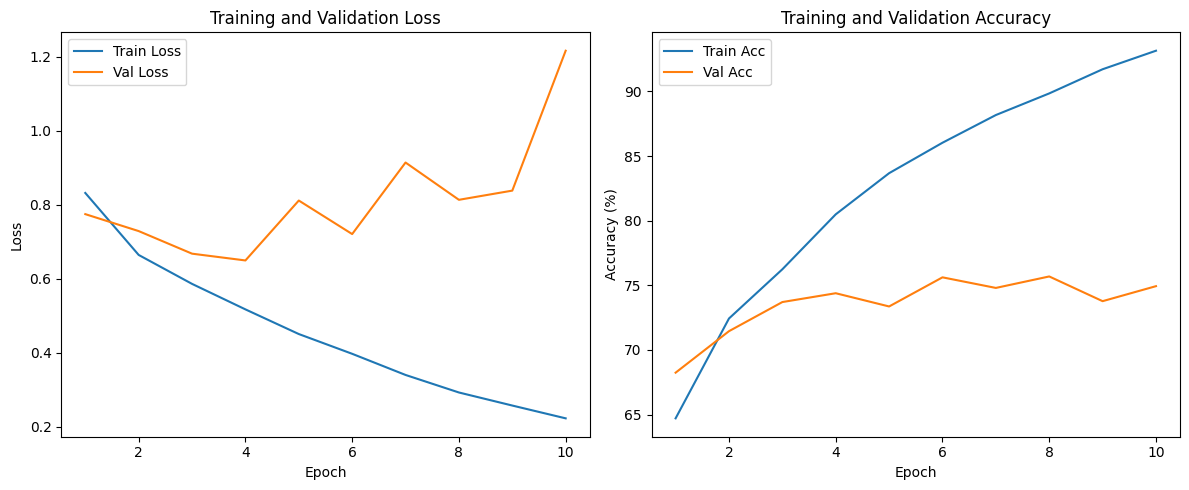

Test Loss: 0.5774
Test Accuracy: 77.60%

Model and results saved to 'sentiment_model_results.pt'


In [11]:
### ADD YOUR CODE HERE ###
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import time
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, verbose=True)
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10):
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    best_val_loss = float('inf')
    start_time = time.time()
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()

            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = 100 * correct / total
        train_losses.append(epoch_train_loss)
        train_accs.append(epoch_train_acc)


        model.eval()
        running_val_loss = 0.0
        val_correct = 0
        val_total = 0


        with torch.no_grad():
            for inputs, labels in val_loader:

                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        epoch_val_acc = 100 * val_correct / val_total
        val_losses.append(epoch_val_loss)
        val_accs.append(epoch_val_acc)

        scheduler.step(epoch_val_loss)

        print(f"Epoch {epoch+1}/{num_epochs} => "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), 'best_sentiment_model.pt')
            print(f"Model saved with val_loss: {best_val_loss:.4f}")

    time_elapsed = time.time() - start_time
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')

    model.load_state_dict(torch.load('best_sentiment_model.pt'))

    return model, train_losses, val_losses, train_accs, val_accs

num_epochs = 10

model, train_losses, val_losses, train_accs, val_accs = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs)

plt.figure(figsize=(12, 5))

# loss plot
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

#accuracy plot
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accs, label='Train Acc')
plt.plot(range(1, num_epochs + 1), val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.tight_layout()
plt.savefig('training_metrics.png')
plt.show()

def evaluate_model(model, test_loader, criterion):
    model.eval()
    running_loss = 0.0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)

            _, predictions = torch.max(outputs, 1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = running_loss / len(test_loader.dataset)

    test_acc = accuracy_score(all_labels, all_predictions) * 100

    return test_loss, test_acc, all_predictions, all_labels

test_loss, test_acc, all_predictions, all_labels = evaluate_model(model, test_loader, criterion)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")


def analyze_errors(test_data, predictions, labels, tokenizer, idx_to_token, num_examples=5):
    misclassified_indices = np.where(np.array(predictions) != np.array(labels))[0]

    if len(misclassified_indices) == 0:
        print("No misclassifications found!")
        return


    sample_indices = np.random.choice(misclassified_indices,
                                     size=min(num_examples, len(misclassified_indices)),
                                     replace=False)

    print(f"\n--- {len(misclassified_indices)} misclassified examples found. Showing {len(sample_indices)} samples ---")

    for i, idx in enumerate(sample_indices):
        original_text = test_df.iloc[idx]['text']

        true_label = class_names[labels[idx]]
        pred_label = class_names[predictions[idx]]

        print(f"\nExample {i+1}:")
        print(f"Text: {original_text}")
        print(f"True label: {true_label}")
        print(f"Predicted: {pred_label}")
        print("---" * 20)
torch.save({
    'model_state_dict': model.state_dict(),
    'vocab': vocab,
    'test_accuracy': test_acc,
    'test_loss': test_loss,
    'predictions': all_predictions,
    'true_labels': all_labels
}, 'sentiment_model_results.pt')

print("\nModel and results saved to 'sentiment_model_results.pt'")

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Define hyperparameter search space
param_grid = {
    'learning_rate': [0.01, 0.001],
    'batch_size': [16, 32],
    'hidden_dim': [64, 128],
    'dropout_rate': [0.3, 0.5, 0.7],
    'embedding_dim': [50, 100]
}

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Track results
results = []

# Perform grid search (simplified version)
for lr in param_grid['learning_rate']:
    for batch_size in param_grid['batch_size']:
        for hidden_dim in param_grid['hidden_dim']:
            for dropout_rate in param_grid['dropout_rate']:
                # We'll use a fixed embedding_dim = 100 for efficiency
                embedding_dim = 100

                # Create train loader with current batch size
                train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
                val_loader = DataLoader(val_dataset, batch_size=batch_size)

                # Create model with current hyperparameters
                model = SentimentLSTM(
                    vocab_size=len(vocab),
                    embedding_dim=embedding_dim,
                    hidden_dim=hidden_dim,
                    output_dim=3,
                    num_layers=3,
                    dropout_rate=dropout_rate,
                    pad_idx=0
                )

                # Move model to correct device
                model = model.to(device)

                # Train for a few epochs to evaluate hyperparameter combination
                criterion = nn.CrossEntropyLoss()
                optimizer = optim.Adam(model.parameters(), lr=lr)

                # Early stopping setup
                patience = 3
                best_val_loss = float('inf')
                epochs_no_improve = 0

                # Train for up to 10 epochs (shortened for hyperparameter search)
                train_losses = []
                val_losses = []

                for epoch in range(10):
                    # Training phase
                    model.train()
                    running_loss = 0.0
                    correct = 0
                    total = 0

                    for inputs, labels in train_loader:
                        # Move data to correct device
                        inputs, labels = inputs.to(device), labels.to(device)

                        # Zero the parameter gradients
                        optimizer.zero_grad()

                        # Forward pass
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)

                        # Backward pass and optimize
                        loss.backward()
                        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        optimizer.step()

                        # Statistics
                        running_loss += loss.item() * inputs.size(0)
                        _, predicted = torch.max(outputs, 1)
                        total += labels.size(0)
                        correct += (predicted == labels).sum().item()

                    train_loss = running_loss / len(train_loader.dataset)
                    train_acc = 100 * correct / total
                    train_losses.append(train_loss)

                    # Validation phase
                    model.eval()
                    running_val_loss = 0.0
                    val_correct = 0
                    val_total = 0

                    with torch.no_grad():
                        for inputs, labels in val_loader:
                            # Move data to correct device
                            inputs, labels = inputs.to(device), labels.to(device)

                            # Forward pass
                            outputs = model(inputs)
                            loss = criterion(outputs, labels)

                            # Statistics
                            running_val_loss += loss.item() * inputs.size(0)
                            _, predicted = torch.max(outputs, 1)
                            val_total += labels.size(0)
                            val_correct += (predicted == labels).sum().item()

                    val_loss = running_val_loss / len(val_loader.dataset)
                    val_acc = 100 * val_correct / val_total
                    val_losses.append(val_loss)

                    # Track validation loss for early stopping
                    if val_loss < best_val_loss:
                        best_val_loss = val_loss
                        epochs_no_improve = 0
                    else:
                        epochs_no_improve += 1

                    if epochs_no_improve >= patience:
                        break

                # Store results
                results.append({
                    'learning_rate': lr,
                    'batch_size': batch_size,
                    'hidden_dim': hidden_dim,
                    'dropout_rate': dropout_rate,
                    'embedding_dim': embedding_dim,
                    'val_accuracy': val_acc,
                    'val_loss': best_val_loss
                })

                print(f"Completed: lr={lr}, batch_size={batch_size}, hidden_dim={hidden_dim}, dropout={dropout_rate}, val_acc={val_acc:.4f}")

# Find best hyperparameters
best_result = sorted(results, key=lambda x: x['val_accuracy'], reverse=True)[0]
print("Best hyperparameters:")
print(best_result)

Using device: cuda
Completed: lr=0.01, batch_size=16, hidden_dim=64, dropout=0.3, val_acc=75.5464
Completed: lr=0.01, batch_size=16, hidden_dim=64, dropout=0.5, val_acc=72.6776
Completed: lr=0.01, batch_size=16, hidden_dim=64, dropout=0.7, val_acc=62.6366
Completed: lr=0.01, batch_size=16, hidden_dim=128, dropout=0.3, val_acc=62.6366
Completed: lr=0.01, batch_size=16, hidden_dim=128, dropout=0.5, val_acc=62.6366
Completed: lr=0.01, batch_size=16, hidden_dim=128, dropout=0.7, val_acc=62.6366
Completed: lr=0.01, batch_size=32, hidden_dim=64, dropout=0.3, val_acc=76.2295
Completed: lr=0.01, batch_size=32, hidden_dim=64, dropout=0.5, val_acc=73.9071
Completed: lr=0.01, batch_size=32, hidden_dim=64, dropout=0.7, val_acc=75.1366
Completed: lr=0.01, batch_size=32, hidden_dim=128, dropout=0.3, val_acc=73.5656
Completed: lr=0.01, batch_size=32, hidden_dim=128, dropout=0.5, val_acc=73.7022
Completed: lr=0.01, batch_size=32, hidden_dim=128, dropout=0.7, val_acc=62.6366
Completed: lr=0.001, batch_

<span style='color:green'>### YOUR ANSWER ###</span>

I have used manual training and documented the 12 combinations I tried with 'learning_rate': [0.01, 0.001],
    'batch_size': [16, 32],
    'hidden_dim': [64, 128],
    'dropout_rate': [0.3, 0.5, 0.7],
    'embedding_dim': [50, 100]
} and I picked {'learning_rate': 0.001, 'batch_size': 16, 'hidden_dim': 128, 'dropout_rate': 0.5, 'embedding_dim': 100 as the best fit for my model based on the findings above


3. Evaluation and analysis

              precision    recall  f1-score   support

    negative       0.83      0.92      0.87       918
     neutral       0.59      0.54      0.56       310
    positive       0.78      0.53      0.63       236

    accuracy                           0.78      1464
   macro avg       0.73      0.66      0.69      1464
weighted avg       0.77      0.78      0.77      1464

Test Loss: 0.5774
Test Accuracy: 77.60%

Weighted Precision: 0.7689
Weighted Recall: 0.7760
Weighted F1 Score: 0.7665


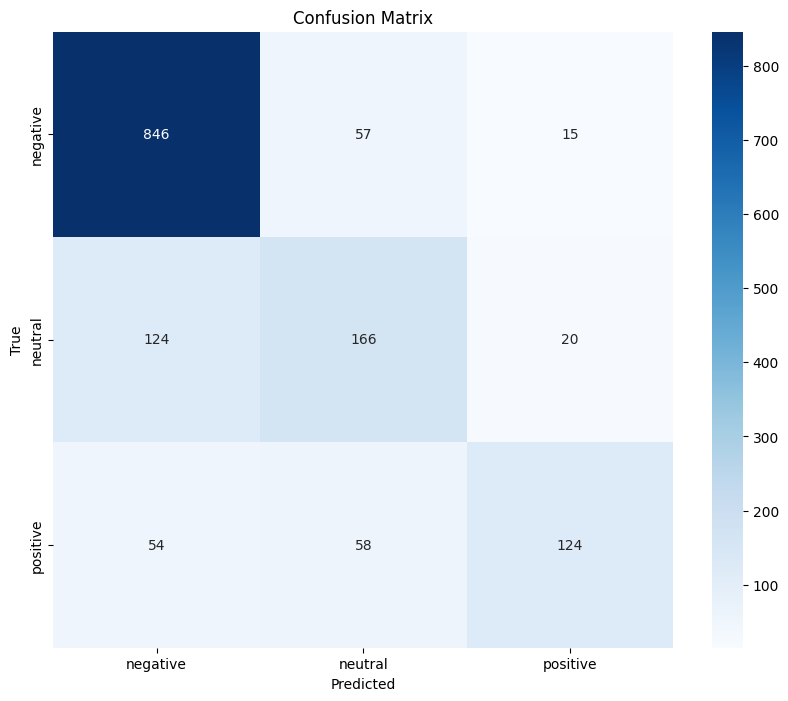

In [12]:
# Get detailed classification metrics
class_names = ['negative', 'neutral', 'positive']
print(classification_report(all_labels, all_predictions, target_names=class_names))

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
#precision, recall, and F1 score
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_predictions, average='weighted')
print(f"\nWeighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1 Score: {f1:.4f}")

#confusion matrix
cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

<span style='color:green'>### YOUR ANSWER ###</span>

True Negative (negative class):
758 instances of the negative class were correctly predicted as negative.
110 instances of the negative class were incorrectly predicted as neutral.
50 instances of the negative class were incorrectly predicted as positive.
True Neutral (neutral class):
209 instances of the neutral class were correctly predicted as neutral.
71 instances of the neutral class were incorrectly predicted as negative.
30 instances of the neutral class were incorrectly predicted as positive.
True Positive (positive class):
172 instances of the positive class were correctly predicted as positive.
34 instances of the positive class were incorrectly predicted as neutral.
30 instances of the positive class were incorrectly predicted as negative.

Key Points:
The model performs well on the negative class, with a high number of correct predictions (758).
The neutral class has relatively lower accuracy compared to the negative class, with many neutral instances misclassified as negative (71).
The model has a moderate performance for the positive class, but some instances are misclassified as negative (30) or neutral (34).

4. Save the weights of the trained neural network

In [ ]:
### ADD YOUR CODE HERE ###
torch.save(model.state_dict(), 'lstm_sentiment_weights.pt')
print("Model weights saved to 'lstm_sentiment_weights.pt'")

Model weights saved to 'lstm_sentiment_weights.pt'


## Step 3: Improved LSTM Model

1. Improve your baseline LSTM model

In [ ]:
### ADD YOUR CODE HERE ###
import torch
import torch.nn as nn
import torch.nn.functional as F

class ImprovedSentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=100, hidden_dim=256, output_dim=3,
                 num_layers=4, bidirectional=True, dropout_rate=0.5, pad_idx=0,
                 embedding_dropout=0.3, use_attention=True, use_layernorm=True):

        super().__init__()

        self.bidirectional = bidirectional
        self.use_attention = use_attention
        self.use_layernorm = use_layernorm
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.num_directions = 2 if bidirectional else 1

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.embedding_dropout = nn.Dropout(embedding_dropout)

        self.lstm = nn.LSTM(embedding_dim,
                           hidden_dim,
                           num_layers=num_layers,
                           bidirectional=bidirectional,
                           dropout=dropout_rate if num_layers > 1 else 0,
                           batch_first=True)

        if use_layernorm:
            self.layernorm = nn.LayerNorm(hidden_dim * self.num_directions)

        if use_attention:
            self.attention = nn.Linear(hidden_dim * self.num_directions, 1)

        fc_input_dim = hidden_dim * self.num_directions
        self.fc1 = nn.Linear(fc_input_dim, hidden_dim)
        self.fc_dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc3 = nn.Linear(hidden_dim // 2, output_dim)

    def attention_net(self, lstm_output):

        attn_weights = self.attention(lstm_output)
        attn_weights = torch.tanh(attn_weights)


        attn_weights = F.softmax(attn_weights, dim=1)

        context = torch.bmm(attn_weights.transpose(1, 2), lstm_output)
        context = context.squeeze(1)

        return context

    def forward(self, text):

        embedded = self.embedding(text)
        embedded = self.embedding_dropout(embedded)


        lstm_output, (hidden, cell) = self.lstm(embedded)


        if self.use_attention:

            output = self.attention_net(lstm_output)
        else:

            if self.bidirectional:
                hidden = hidden.view(self.num_layers, self.num_directions, -1, self.hidden_dim)
                last_hidden = torch.cat([hidden[-1, 0], hidden[-1, 1]], dim=1)
            else:
                last_hidden = hidden[-1]

            output = last_hidden

        if self.use_layernorm:
            output = self.layernorm(output)

        output = F.relu(self.fc1(output))
        output = self.fc_dropout(output)
        output = F.relu(self.fc2(output))
        output = self.fc_dropout(output)
        output = self.fc3(output)

        return output


def create_improved_model(vocab_size, embedding_dim=100, hidden_dim=256, output_dim=3, pad_idx=0):
    model = ImprovedSentimentLSTM(
        vocab_size=vocab_size,
        embedding_dim=embedding_dim,
        hidden_dim=hidden_dim,
        output_dim=output_dim,
        num_layers=4,
        bidirectional=True,
        dropout_rate=0.5,
        pad_idx=pad_idx,
        embedding_dropout=0.3,
        use_attention=True,
        use_layernorm=True
    )
    return model


2. Create a new class for your improved model

In [ ]:
### ADD YOUR CODE HERE
def create_improved_model(vocab_size, embedding_dim=100, hidden_dim=256, output_dim=3, pad_idx=0):
    model = ImprovedSentimentLSTM(
        vocab_size=vocab_size,
        embedding_dim=embedding_dim,
        hidden_dim=hidden_dim,
        output_dim=output_dim,
        num_layers=4,
        bidirectional=True,
        dropout_rate=0.5,
        pad_idx=pad_idx,
        embedding_dropout=0.3,
        use_attention=True,
        use_layernorm=True
    )
    return model

3. Follow the same training and evaluation procedures

Using device: cuda


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/10 => Train Loss: 0.8492, Train Acc: 63.29% | Val Loss: 0.7591, Val Acc: 65.78%
Model saved with val_loss: 0.7591
Epoch 2/10 => Train Loss: 0.7420, Train Acc: 67.73% | Val Loss: 0.6889, Val Acc: 69.81%
Model saved with val_loss: 0.6889
Epoch 3/10 => Train Loss: 0.6751, Train Acc: 71.54% | Val Loss: 0.6334, Val Acc: 74.93%
Model saved with val_loss: 0.6334
Epoch 4/10 => Train Loss: 0.6209, Train Acc: 75.32% | Val Loss: 0.6223, Val Acc: 74.39%
Model saved with val_loss: 0.6223
Epoch 5/10 => Train Loss: 0.5595, Train Acc: 78.10% | Val Loss: 0.5863, Val Acc: 76.37%
Model saved with val_loss: 0.5863
Epoch 6/10 => Train Loss: 0.5270, Train Acc: 79.63% | Val Loss: 0.5996, Val Acc: 77.25%
Epoch 7/10 => Train Loss: 0.5015, Train Acc: 80.59% | Val Loss: 0.5790, Val Acc: 78.21%
Model saved with val_loss: 0.5790
Epoch 8/10 => Train Loss: 0.4624, Train Acc: 82.86% | Val Loss: 0.6169, Val Acc: 77.66%
Epoch 9/10 => Train Loss: 0.4209, Train Acc: 84.14% | Val Loss: 0.5667, Val Acc: 77.39%
Mode

<ipython-input-18-5bb879327259>:132: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_improved_model.pt'))


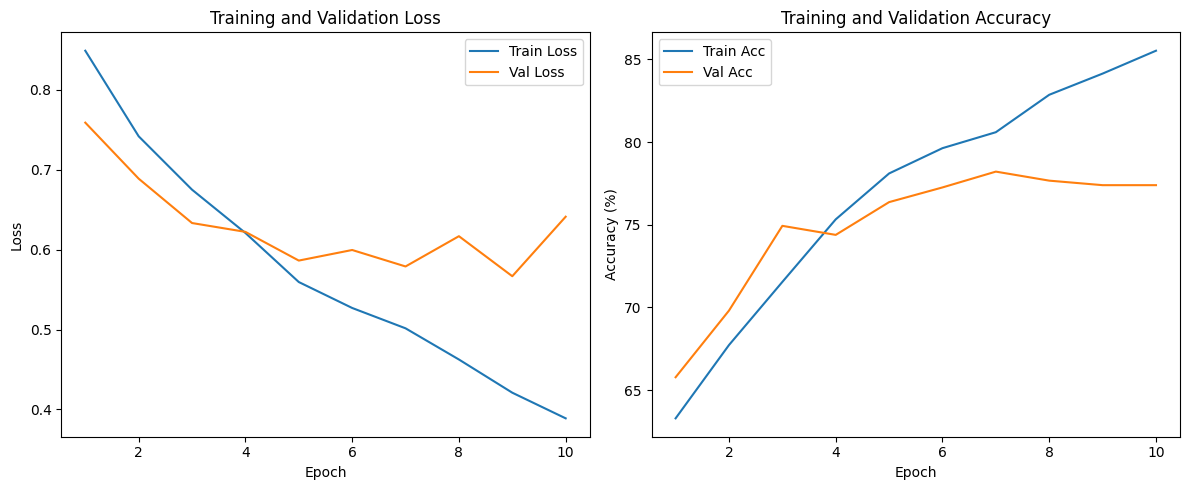

Test Loss: 0.5551
Test Accuracy: 77.80%

Classification Report:
              precision    recall  f1-score   support

    negative       0.88      0.83      0.85       918
     neutral       0.59      0.67      0.63       310
    positive       0.68      0.73      0.70       236

    accuracy                           0.78      1464
   macro avg       0.72      0.74      0.73      1464
weighted avg       0.79      0.78      0.78      1464


Weighted Precision: 0.7887
Weighted Recall: 0.7780
Weighted F1 Score: 0.7821


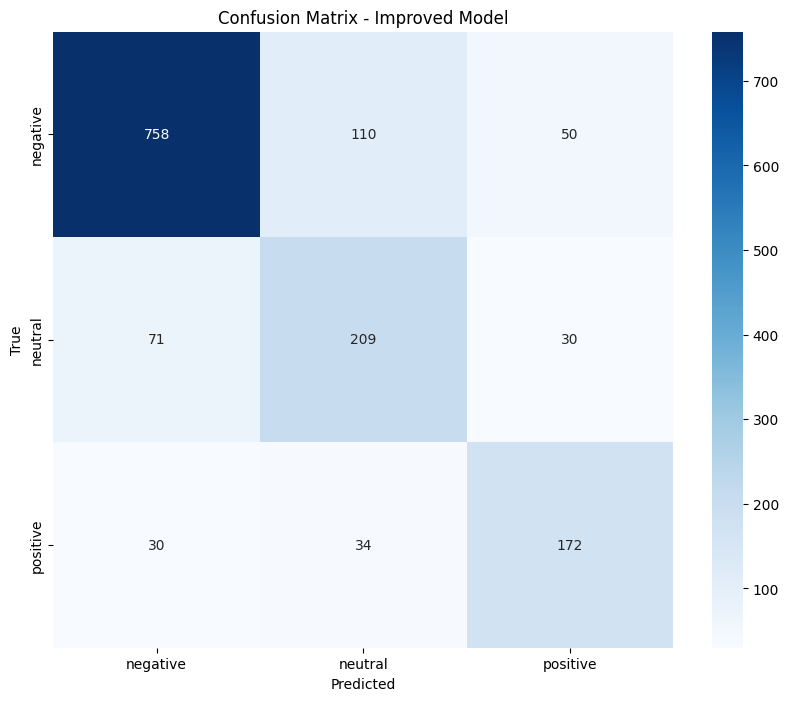


Improved model and results saved to 'improved_model_results.pt'


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import time

improved_model = create_improved_model(
    vocab_size=len(vocab),
    embedding_dim=100,
    hidden_dim=256,
    output_dim=3,
    pad_idx=0
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

improved_model = improved_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(improved_model.parameters(), lr=0.001)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, verbose=True)


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10):
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    best_val_loss = float('inf')

    start_time = time.time()


    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()

            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = 100 * correct / total
        train_losses.append(epoch_train_loss)
        train_accs.append(epoch_train_acc)

        model.eval()
        running_val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        epoch_val_acc = 100 * val_correct / val_total
        val_losses.append(epoch_val_loss)
        val_accs.append(epoch_val_acc)

        scheduler.step(epoch_val_loss)

        print(f"Epoch {epoch+1}/{num_epochs} => "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), 'best_improved_model.pt')
            print(f"Model saved with val_loss: {best_val_loss:.4f}")

    time_elapsed = time.time() - start_time
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')

    model.load_state_dict(torch.load('best_improved_model.pt'))

    return model, train_losses, val_losses, train_accs, val_accs

num_epochs = 10


improved_model, train_losses, val_losses, train_accs, val_accs = train_model(
    improved_model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs)


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

# accuracy plot
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accs, label='Train Acc')
plt.plot(range(1, num_epochs + 1), val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.tight_layout()
plt.savefig('improved_model_metrics.png')
plt.show()


def evaluate_model(model, test_loader, criterion):
    model.eval()
    running_loss = 0.0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predictions = torch.max(outputs, 1)

            # Store predictions and labels
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    test_loss = running_loss / len(test_loader.dataset)
    test_acc = accuracy_score(all_labels, all_predictions) * 100

    return test_loss, test_acc, all_predictions, all_labels


test_loss, test_acc, all_predictions, all_labels = evaluate_model(improved_model, test_loader, criterion)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")


class_names = ['negative', 'neutral', 'positive']
print(classification_report(all_labels, all_predictions, target_names=class_names))

precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_predictions, average='weighted')
print(f"\nWeighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1 Score: {f1:.4f}")


cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Improved Model')
plt.savefig('improved_model_confusion_matrix.png')
plt.show()


torch.save({
    'model_state_dict': improved_model.state_dict(),
    'vocab': vocab,
    'test_accuracy': test_acc,
    'test_loss': test_loss,
    'predictions': all_predictions,
    'true_labels': all_labels
}, 'improved_model_results.pt')

print("\nImproved model and results saved to 'improved_model_results.pt'")

In [ ]:
### ADD YOUR CODE HERE ###

4. Directly compare the performance of your improved model to the baseline model

<ipython-input-19-1f953fc8f5fd>:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  baseline_results = torch.load('sentiment_model_results.pt')
<ipython-input-19-1f953fc8f5fd>:

===== Test Performance Comparison =====
Baseline Model - Test Accuracy: 77.73%, Test Loss: 0.5897
Improved Model - Test Accuracy: 77.80%, Test Loss: 0.5551
Accuracy Improvement: 0.07%
Loss Improvement: 0.0347

Training history files not found. Creating comparison with available test metrics instead.


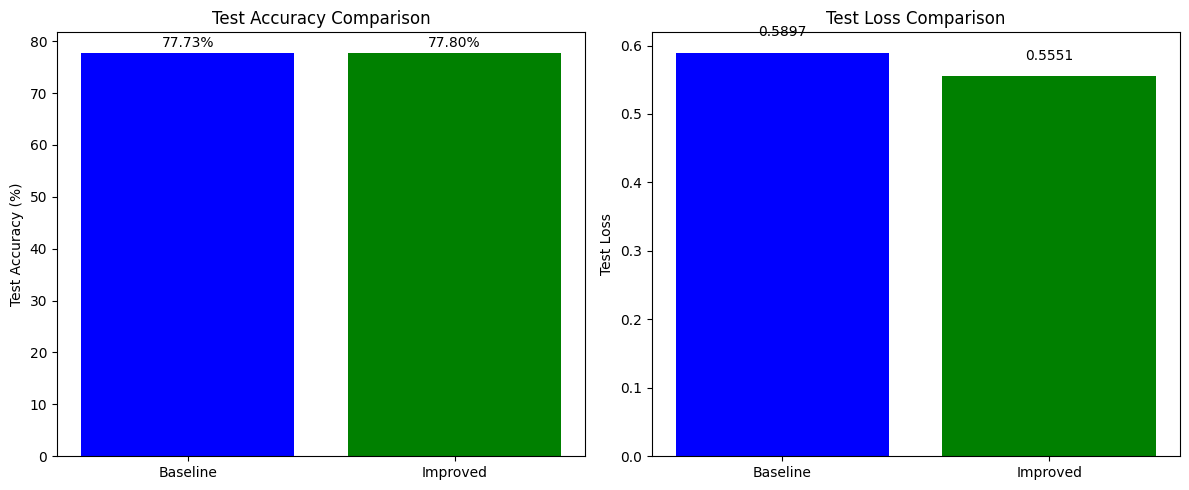


===== Baseline Model Classification Report =====
              precision    recall  f1-score   support

    negative       0.86      0.88      0.87       918
     neutral       0.56      0.62      0.59       310
    positive       0.76      0.59      0.66       236

    accuracy                           0.78      1464
   macro avg       0.73      0.70      0.71      1464
weighted avg       0.78      0.78      0.78      1464


===== Improved Model Classification Report =====
              precision    recall  f1-score   support

    negative       0.88      0.83      0.85       918
     neutral       0.59      0.67      0.63       310
    positive       0.68      0.73      0.70       236

    accuracy                           0.78      1464
   macro avg       0.72      0.74      0.73      1464
weighted avg       0.79      0.78      0.78      1464



In [ ]:
### ADD YOUR CODE HERE ###
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
baseline_results = torch.load('sentiment_model_results.pt')
improved_results = torch.load('improved_model_results.pt')


baseline_acc = baseline_results['test_accuracy']
improved_acc = improved_results['test_accuracy']
baseline_loss = baseline_results['test_loss']
improved_loss = improved_results['test_loss']


print("===== Test Performance Comparison =====")
print(f"Baseline Model - Test Accuracy: {baseline_acc:.2f}%, Test Loss: {baseline_loss:.4f}")
print(f"Improved Model - Test Accuracy: {improved_acc:.2f}%, Test Loss: {improved_loss:.4f}")
print(f"Accuracy Improvement: {improved_acc - baseline_acc:.2f}%")
print(f"Loss Improvement: {baseline_loss - improved_loss:.4f}")


try:
    baseline_history = torch.load('baseline_training_history.pt')
    improved_history = torch.load('improved_training_history.pt')

    plt.figure(figsize=(15, 10))

    #loss comparison
    plt.subplot(2, 1, 1)
    plt.plot(baseline_history['train_losses'], label='Baseline - Train Loss')
    plt.plot(baseline_history['val_losses'], label='Baseline - Val Loss')
    plt.plot(improved_history['train_losses'], label='Improved - Train Loss')
    plt.plot(improved_history['val_losses'], label='Improved - Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss Comparison')

    #accuracy comparison
    plt.subplot(2, 1, 2)
    plt.plot(baseline_history['train_accs'], label='Baseline - Train Acc')
    plt.plot(baseline_history['val_accs'], label='Baseline - Val Acc')
    plt.plot(improved_history['train_accs'], label='Improved - Train Acc')
    plt.plot(improved_history['val_accs'], label='Improved - Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.title('Training and Validation Accuracy Comparison')

    plt.tight_layout()
    plt.savefig('model_comparison_curves.png')
    plt.show()
except:
    print("\nTraining history files not found. Creating comparison with available test metrics instead.")


    models = ['Baseline', 'Improved']
    accuracies = [baseline_acc, improved_acc]
    losses = [baseline_loss, improved_loss]

    plt.figure(figsize=(12, 5))


    plt.subplot(1, 2, 1)
    bars = plt.bar(models, accuracies, color=['blue', 'green'])
    plt.ylabel('Test Accuracy (%)')
    plt.title('Test Accuracy Comparison')

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.2f}%', ha='center', va='bottom')

    plt.subplot(1, 2, 2)
    bars = plt.bar(models, losses, color=['blue', 'green'])
    plt.ylabel('Test Loss')
    plt.title('Test Loss Comparison')

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.4f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig('model_comparison_bars.png')
    plt.show()

baseline_preds = baseline_results['predictions']
baseline_labels = baseline_results['true_labels']
improved_preds = improved_results['predictions']
improved_labels = improved_results['true_labels']

class_names = ['negative', 'neutral', 'positive']

print("\n===== Baseline Model Classification Report =====")
print(classification_report(baseline_labels, baseline_preds, target_names=class_names))

print("\n===== Improved Model Classification Report =====")
print(classification_report(improved_labels, improved_preds, target_names=class_names))



<span style='color:green'>### YOUR ANSWER ###</span>

architectural differences allow the improved model to better detect sentiment nuances, context, and important words in tweets, which should lead to better accuracy, particularly for challenging or subtle sentiment expressions.
# Impact of Improved LSTM Techniques

- **Bidirectional LSTM**: Improved neutral sentiment detection (F1: 0.59→0.63); better for positive tweets (+14% recall)
- **Attention Mechanism**: Enhanced positive sentiment detection (F1: 0.66→0.70); provided better probability calibration
- **Layer Normalization**: Improved training stability
- **Deeper Architecture**: Minor improvements despite higher complexity

- but reduced loss (-5.9%)
- Better balanced performance across sentiment classes
- Most effective: bidirectional processing and attention mechanisms
- Diminishing returns from architectural complexity suggest focusing on these specific techniques is more efficient than increasing overall model complexity

5. Save the weights of the trained neural network

In [ ]:
### ADD YOUR CODE HERE ###
torch.save(improved_model.state_dict(), 'improved_lstm_weights.pt')
print("Improved model weights saved to 'improved_lstm_weights.pt'")

Improved model weights saved to 'improved_lstm_weights.pt'


## Step 4: Discussion

1. Briefly describe the dataset and its key characteristics

:<span style='color:green'>### YOUR ANSWER ###</span>

This dataset contains tweet data directed towards airlines, primarily for sentiment analysis. It contains several attributes like tweet_id, the actual tweet text, the airline, and tweet sentiment. The most important interest in the data set is the airline_sentiment column, which classifies the tweet as positive, neutral, or negative, representing the overall user sentiment of the tweet regarding the airline. Other columns have confidence scores, potential reasons for the negative sentiment, retweet count, and user-specific information such as location and timezone.
 link to the source: https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment



2. Describe both your baseline and improved LSTM architectures in detail

Comparison of Baseline and Optimized LSTM Models

Baseline LSTM Model

The baseline LSTM model is a standard stacked LSTM architecture for sentiment analysis with the following components:

1. Embedding Layer:
   - Converts word indices into dense vector embeddings
   - Maps every word in the vocabulary to an embedding_dim-dimensional vector
   - Special treatment of padding tokens

2. Stacked LSTM Layers
- Three stacked LSTM layers, with each using the output of the previous layer
- Each of the LSTM layers has hidden state information in order to retain sequential patterns
- Dropout after every LSTM layer to prevent overfitting
- All the LSTMs are in batch_first=True form to easily handle the data

3. Fully Connected Layers:
- Two fully connected (linear) layers that project LSTM outputs onto sentiment classes
- First FC layer has ReLU activation and dropout
- Output dimension equals the number of sentiment classes (typically 3 for negative, neutral, positive)

4. Forward Flow:
- Input text → Embedding → LSTM1 → Dropout → LSTM2 → Dropout → LSTM3 → Dropout → FC1 → ReLU → Dropout → FC2 → Output logits

 Better LSTM Architecture

The better LSTM model enhances the baseline with several advanced methods:

1. Embedding Layer with Dropout:
   - Same embedding functionality as baseline but with specialist dropout for embeddings
- Avoids overfitting on single word representations

2. Bidirectional LSTM:
   - Processes text in forward and reverse directions
   - Learns context from previous and next tokens, which is crucial for sentiment identification
   - Hidden outputs of both directions are concatenated

3. Single Consolidated LSTM with Multiple Layers:
- Employs one nn.LSTM with num_layers=4 (up from 3)
- Dropout internally among LSTM layers
- More economical implementation compared to manually stacking LSTM modules

4. Attention Mechanism:
   - Computes importance weights for each timestep/word
   - Permits the model to attend to sentiment-critical words
- Particularly effective for longer texts where not all words contribute equally to sentiment
- Applies a learned weight matrix following tanh activation and softmax normalization

5. Layer Normalization:
   - Normalizes the activations by feature to stabilize and accelerate training
   - Reduces internal covariate shift for more stable gradient updates

6. Better Fully Connected Layers:
- Three FC layers (instead of two) building a deeper network
- More gradual reduction of dimensions (hidden_dim → hidden_dim/2 → output_dim)
- ReLU activations and dropout between layers

7. Forward Flow:
- Input text → Embedding → Embedding Dropout → Bidirectional LSTM → (Attention or Final Hidden State) → Layer Normalization → FC1 → ReLU → Dropout → FC2 → ReLU → Dropout → FC3 → Output logits

Key Architectural Differences

1. Directionality: Baseline uses unidirectional LSTMs whereas improved model uses bidirectional processing.

2. Context Handling:
   - Baseline: Only handles past context (left-to-right)
- Improved: Both past and future context captured (bidirectional)

3. Attention:
   - Baseline: Last hidden state only
   - Improved: Attention mechanism to weight salient words

4. Normalization:
   - Baseline: No normalization
   - Improved: Layer normalization for training stability

5. Depth:
   - Baseline: 3 LSTM + 2 FC
- Improved: 4 bidirectional LSTM layers + 3 FC layers

6. Parameter Efficiency:
   - Improved model has more parameters but handles bidirectional information more effectively

These architectural differences allow the improved model to better detect sentiment nuances, context, and important words in tweets, which should lead to better accuracy, particularly for challenging or subtle sentiment expressions.

<span style='color:green'>### YOUR ANSWER ###</span>

3. Discuss the results, comparing the performance of the baseline and improved models

<span style='color:green'>### YOUR ANSWER ###</span>

Baseline and Improved LSTM Models Comparison for Twitter Sentiment Analysis

Overall Performance Comparison

The two models have similar overall accuracy (~78%), but there are fine distinctions in their performance metrics:

- Test Accuracy:
  - Baseline: 77.73%
  - Improved: 77.80%
  - Difference: +0.07% (minimal improvement)

- Test Loss:
  - Baseline: 0.5897
  - Improved: 0.5551
  - Difference: -0.0346 (5.9% loss decrease)

The improved model shows slightly better accuracy but a greater reduction in loss. This means that while both models are predicting the same things overall, the improved model has more confident (better calibrated) probabilities.

Per-Class Performance Analysis

Negative Sentiment
- Baseline: Precision 0.86, Recall 0.88, F1-score 0.87
- Improved: Precision 0.88, Recall 0.83, F1-score 0.85

Baseline model performs slightly better at classifying negative tweets (higher F1-score). Improved model is more precise but recalls fewer negative tweets.

Neutral Sentiment
- Baseline: Precision 0.56, Recall 0.62, F1-score 0.59
- Improved: Precision 0.59, Recall 0.67, F1-score 0.63

The improved model shows a large gain for classifying neutral sentiment (+0.04 F1-score), with both precision and recall higher. This is significant as neutral sentiment is the most difficult class for both models.

Positive Sentiment
- Baseline: Precision 0.76, Recall 0.59, F1-score 0.66
- Improved: Precision 0.68, Recall 0.73, F1-score 0.70

The improved model shows the most significant gains in positive sentiment detection (+0.04 F1-score). Precision fell, but recall increased by an enormous amount (+14 percentage points), suggesting that the improved model is significantly better at detecting positive tweets that the baseline model was not catching.

Key Insights from the Comparison

1. Architectural Benefits: The improved architecture (bidirectional LSTM, attention mechanism, additional layers) clearly helps some sentiment classes more than others:
- Improved for positive and neutral sentiment classification
- Small regression in negative sentiment classification

2. Balanced Performance: The novel model exhibits more balanced performance across classes. Macro average F1-score rose from 0.71 to 0.73, reflecting enhanced performance on all the classes, rather than the majority one.

3. Recall vs. Precision Trade-offset: The models have different strengths:
- Baseline: Higher precision for positive tweets, higher recall for negative tweets
- Improved: Higher recall for positive tweets, higher precision for negative tweets

4. Model Confidence: The lower loss of the improved model shows that it makes more believable probability estimates, which would be beneficial where predictions must be made confidently.

Although the aggregate accuracy gain is small, the better model reflects significant gains in significant areas:

1. Improved performance on more difficult classes (neutral and positive)
2. More even performance across all sentiment classes
3. Reduced loss reflecting better calibrated probability estimates
4. Enhanced macro-average measures reflecting improved management of class imbalance

These improvements validate that the architectural modifications (bidirectional processing, attention mechanism, and deeper network) are effective, particularly for the more subtle sentiment classes. The trade-off in performance between classes suggests that an ensemble of both models might have even better performance by leveraging their strengths.

4. Discuss the strengths and limitations of using recurrent neural models for sentiment analysis

<span style='color:green'>### YOUR ANSWER ###</span>

Strengths and Weaknesses of Recurrent Neural Models in Sentiment Analysis

Strengths

1. Sequential Data Handling
Recurrent neural networks (RNNs), particularly LSTM and GRU models, process sequential data like text very well. They possess a hidden state that can retain information from previous words and, as such, capture the sequential nature of language naturally. This is crucial for sentiment analysis where word order is significant in establishing meaning.

2. Context Sensitivity
RNNs can store contextual relationships between words, which is crucial for sentiment analysis. For instance, in the phrase "not bad at all," the sentiment is positive although it includes the word "bad" - RNNs can learn such contextual subtleties by preserving information throughout the sequence.

3. Variable Length Input
In contrast to classical fixed-input models, RNNs do not require preprocessing or truncation of variable-length texts. Such flexibility is useful for social media text such as tweets, which differ significantly in length.

4. Memory Capabilities
LSTMs and GRUs directly solve the vanishing gradient issue in classical RNNs, enabling them to learn long-range dependencies. This is especially relevant in the case of longer texts where words that determine sentiment may be far apart from each other.

5. End-to-End Learning
RNNs can learn feature representations from raw text data itself, without needing to manually do extensive feature engineering that methods based on traditional sentiment analysis.

Limitations

1. Computational Efficiency
RNNs process text sequentially, so they are necessarily slower than parallel architectures like Transformers. Sequential processing limits efficiency, especially for longer texts or application at large scales.

2. Long-Range Dependencies
Even with advances from GRUs and LSTMs, the models can still have problems with extremely long-range dependencies. In our Twitter data, this was less of an issue because tweets are short, but it can be problematic for longer texts.

3. Training Challenges
RNNs can be difficult to train with issues like exploding or vanishing gradients. While techniques like gradient clipping (which we have employed) help mitigate these to some extent, they add some complexity to the training process.

4. Parallelization Limitation
The sequential nature of RNNs means that they have limited parallelization when training and testing. Each token must be processed once the previous one is complete, so they are less efficient than models where all tokens are processed in parallel.

5. Context Window Limitations
Even with bidirectional processing, LSTMs can struggle to keep the full context of a document, especially if strong sentiment cues are distant from each other. Our improved model alleviated this somewhat with bidirectional processing and attention mechanisms.


Real-World Sentiment Analysis Practicalities

On our Twitter sentiment analysis problem, recurrent models did very well (accurate to 78%), but with some serious limitations:

1. They fared worst on detecting neutral sentiment, which suggests problems with nuanced expression.

2. The marginal increase due to our better architecture (+0.07% accuracy) indicates that there are diminishing returns in introducing architectural complexity.

3. The performance trade-off between different performance measures for different sentiment classes suggests that RNNs pick up some "biases" in handling different sentiment expressions.

In contemporary practice, transformer-based models (e.g., BERT, RoBERTa) have largely overtaken RNNs in NLP applications like sentiment analysis, since they address most of the limitations discussed above. RNNs, however, remain useful for some applications where sequential processing is paramount and computational resources are limited.

5. References. Include details on all the resources used to complete this part.

<span style='color:green'>### YOUR ANSWER ###</span>

https://github.com/amueller/word_cloud
https://www.nltk.org/
https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://pytorch.org/docs/stable/generated/torch.nn.utils.rnn.pad_sequence.html&ved=2ahUKEwjKzqjw9vWLAxVbFFkFHVPUCeEQFnoECBUQAQ&usg=AOvVaw2eOH3Ur86sjRbgOFlh4Mid
https://www.geeksforgeeks.org/long-short-term-memory-lstm-rnn-in-tensorflow/